# Week 4, Day 3 — From "What is the data?" to "What does it MEAN?"

---

## Today's Journey (2.5 Hours)

| Part | Topic | Duration |
|------|--------|----------|
| 1 | Recap + Today's Promise | ~10 min |
| 2 | Introduction to SciPy | ~20 min |
| 3 | Descriptive Statistics — Shape of Data | ~25 min |
| ☕ | **BREAK 1** | 10 min |
| 4 | Probability Distributions | ~30 min |
| 5 | Hypothesis Testing: T-Tests & ANOVA | ~35 min |
| ☕ | **BREAK 2** | 10 min |
| 6 | Linear Regression & Correlation | ~25 min |
| 7 | Wrap Up + Daily Challenge | ~5 min |

---
```

```text
╔══════════════════════════════════════════════════════════════════════════════╗
║                                                                            ║
║  TODAY'S PROMISE                                                           ║
║                                                                            ║
║  By the end of this session you will be able to answer:                   ║
║                                                                            ║
║  "Is the difference I see in this data REAL,                              ║
║   or is it just random noise?"                                            ║
║                                                                            ║
╚══════════════════════════════════════════════════════════════════════════════╝
```

# Part 2: Introduction to SciPy

## The Scientific Powerhouse Built on NumPy

### NumPy vs SciPy — Who Does What?

| Task | NumPy | SciPy |
|------|--------|--------|
| Mean, std, median | `np.mean()`, `np.std()` | `stats.describe()` |
| Skewness & kurtosis | Manual formula | `stats.skew()`, `stats.kurtosis()` |
| Normal distribution | `np.random.normal()` | `stats.norm.pdf()`, `cdf()`, `ppf()` |
| T-test | ❌ | `stats.ttest_ind()` |
| ANOVA | ❌ | `stats.f_oneway()` |
| Correlation (Pearson) | `np.corrcoef()` | `stats.pearsonr()` *(gives p-value!)* |
| Correlation (Spearman) | ❌ | `stats.spearmanr()` |
| Linear regression | `np.polyfit()` | `stats.linregress()` *(full output)* |

---

### 💡 Key Insight

> **SciPy almost always gives you the p-value along with the statistic.**
>
> That's the superpower — the number that answers:
>
> **"Is this real or just noise?"**
```

# Exercise 1: Your First SciPy Stats Call

Use `scipy.stats` to explore the `tip` column from the `tips` dataset.

## Tasks

1. Call `stats.describe()` on `tips["tip"].values` and print each field with a label.

2. Calculate and print the skewness with `stats.skew()`.

3. Calculate and print the kurtosis with `stats.kurtosis()`.

4. Print a one-line interpretation:
   - Is the tip distribution symmetric?
   - If not, skewed which way?

### Functions to Use

```python
from scipy import stats

stats.describe()
stats.skew()
stats.kurtosis()
```

### Goal

By the end of this exercise, you should be able to:

- Summarize a distribution using SciPy.
- Measure skewness.
- Measure kurtosis.
- Interpret the shape of a dataset.
```

In [6]:
# Setup - run this first!
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd
import warnings
import scipy
warnings.filterwarnings("ignore")

# Notebook display settings
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
np.random.seed(42)

print("All libraries loaded!")
print(f"NumPy version : {np.__version__}")
print(f"SciPy version : {scipy.__version__}")
print(f"Pandas version : {pd.__version__}")

All libraries loaded!
NumPy version : 2.4.6
SciPy version : 1.17.1
Pandas version : 3.0.3


In [7]:
# Load the tips dataset – our companion for today
tips = sns.load_dataset("tips")

print("Dataset shape:", tips.shape)
print("\nFirst 5 rows:")
print(tips.head().to_string())
print("\nColumn types:")
print(tips.dtypes)
print("\nQuick stats:")
print(tips.describe().round(2).to_string())

Dataset shape: (244, 7)

First 5 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Column types:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Quick stats:
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


# Exercise 1: Your First SciPy Stats Call

Use `scipy.stats` to explore the `tip` column from the `tips` dataset.

## Tasks

1. Call `stats.describe()` on `tips["tip"].values` and print each field with a label.

2. Calculate and print the skewness with `stats.skew()`.

3. Calculate and print the kurtosis with `stats.kurtosis()`.

4. Print a one-line interpretation:
   - Is the tip distribution symmetric?
   - If not, skewed which way?

### Example Template

```python
from scipy import stats

# 1. Summary statistics
description = stats.describe(tips["tip"].values)
print(description)

# 2. Skewness
print(stats.skew(tips["tip"].values))

# 3. Kurtosis
print(stats.kurtosis(tips["tip"].values))

# 4. Interpretation
print("Interpret the shape of the distribution here.")
```

In [9]:
# Exercise 1 – Your First SciPy Stats Call
# Task: describe the tip column using scipy.stats

tip_data = tips["tip"].values

# 1. Use stats.describe() – it returns a named tuple
desc = stats.describe(tip_data)
print(f"Count : {desc.nobs}")
print(f"Min/Max: {desc.minmax}")
print(f"Mean : {desc.mean:.4f}")
print(f"Variance: {desc.variance:.4f}")

# 2. Skewness
sk = stats.skew(tip_data)
print(f"Skewness : {sk:.4f}")

# 3. Kurtosis
kurt = stats.kurtosis(tip_data)
print(f"Kurtosis : {kurt:.4f}")

# 4. Interpretation
interpretation = (
    "right-skewed (positive skew): most tips are small, with a tail of large tips"
    if sk > 0.5 else
    "left-skewed (negative skew): a tail of small tips"
    if sk < -0.5 else
    "roughly symmetric"
)
print("\nInterpretation:", interpretation)


Count : 244
Min/Max: (np.float64(1.0), np.float64(10.0))
Mean : 2.9983
Variance: 1.9145
Skewness : 1.4564
Kurtosis : 3.5496

Interpretation: right-skewed (positive skew): most tips are small, with a tail of large tips


# Part 3: Descriptive Statistics — Shape of Data

## Beyond Mean and Standard Deviation

### `stats.describe()` — Your Statistical X-Ray

```python
result = stats.describe(data)
```

Returns a named tuple with:

| Field | Description | Pandas Equivalent |
|--------|-------------|------------------|
| `nobs` | Number of observations | `len(data)` |
| `minmax` | `(min, max)` tuple | `data.min(), data.max()` |
| `mean` | Arithmetic mean | `data.mean()` |
| `variance` | Sample variance (*n - 1*) | `data.var(ddof=1)` |
| `skewness` | Asymmetry: >0 right tail, <0 left tail | `data.skew()` |
| `kurtosis` | Tail weight vs normal: >0 heavier tails | `data.kurt()` |

---

## Skewness Rules of Thumb

- `|skew| < 0.5` → approximately symmetric
- `0.5 ≤ |skew| < 1.0` → moderately skewed
- `|skew| ≥ 1.0` → highly skewed

---

> **Transition:** Great — you've called SciPy. You got numbers back.
>
> But what do those numbers **MEAN**?
>
> What is **skewness**, really?
>
> Let's build the intuition before we go further.
```

```python
# Live Demo: NumPy vs SciPy — what each gives us

# Your code here
```

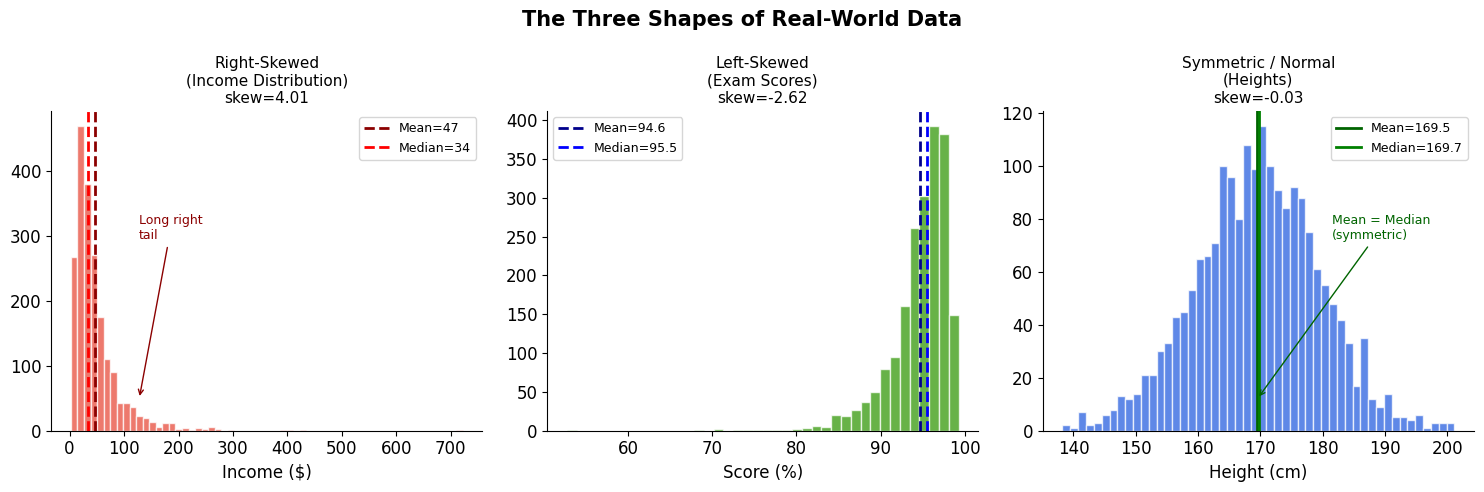


Key takeaway:
    Right-skewed: mean > median (the tail pulls mean up)
    Left-skewed: mean < median (the tail pulls mean down)
    Symmetric: mean = median


In [11]:
# Visual: Three Distribution Shapes - income, exam scores, heights
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("The Three Shapes of Real-World Data", fontsize=15, fontweight="bold")

np.random.seed(42)

# Right-skewed: income (log-normal)
income = np.random.lognormal(mean=3.5, sigma=0.8, size=2000)
ax0 = axes[0]
ax0.hist(income, bins=60, color="#E74C3C", alpha=0.75, edgecolor="white")
ax0.axvline(np.mean(income), color="darkred", lw=2, linestyle="--", label=f"Mean={np.mean(income):.0f}")
ax0.axvline(np.median(income), color="red", lw=2, linestyle="--", label=f"Median={np.median(income):.0f}")
sk0 = stats.skew(income)
ax0.set_title(f"Right-Skewed\n(Income Distribution)\nskew={sk0:.2f}", fontsize=11)
ax0.set_xlabel("Income ($)")
ax0.legend(fontsize=9)
ax0.annotate("Long right\ntail",
             xy=(np.percentile(income, 95), ax0.get_ylim()[1] * 0.1),
             xytext=(np.percentile(income, 95), ax0.get_ylim()[1] * 0.6),
             arrowprops=dict(arrowstyle="->", color="darkred"),
             fontsize=9, color="darkred")

# Left-skewed: exam scores with easy test
exam = 100 - np.random.lognormal(mean=1.5, sigma=0.6, size=2000)
exam = np.clip(exam, 40, 100)
ax1 = axes[1]
ax1.hist(exam, bins=40, color="#34980B", alpha=0.75, edgecolor="white")
ax1.axvline(np.mean(exam), color="darkblue", lw=2, linestyle="--", label=f"Mean={np.mean(exam):.1f}")
ax1.axvline(np.median(exam), color="blue", lw=2, linestyle="--", label=f"Median={np.median(exam):.1f}")
sk1 = stats.skew(exam)
ax1.set_title(f"Left-Skewed\n(Exam Scores)\nskew={sk1:.2f}", fontsize=11)
ax1.set_xlabel("Score (%)")
ax1.legend(fontsize=9)
ax1.annotate("Long left\ntail",
             xy=(50, ax1.get_ylim()[1] * 0.1),
             xytext=(62, ax1.get_ylim()[1] * 0.6),
             arrowprops=dict(arrowstyle="->", color="darkblue"),
             fontsize=9, color="darkblue")

# Symmetric: heights
heights = np.random.normal(loc=170, scale=10, size=2000)
ax2 = axes[2]
ax2.hist(heights, bins=50, color="#2A60E0", alpha=0.75, edgecolor="white")
ax2.axvline(np.mean(heights), color="darkgreen", lw=2, linestyle="-", label=f"Mean={np.mean(heights):.1f}")
ax2.axvline(np.median(heights), color="green", lw=2, linestyle="-", label=f"Median={np.median(heights):.1f}")
sk2 = stats.skew(heights)
ax2.set_title(f"Symmetric / Normal\n(Heights)\nskew={sk2:.2f}", fontsize=11)
ax2.set_xlabel("Height (cm)")
ax2.legend(fontsize=9)
ax2.annotate("Mean = Median\n(symmetric)",
             xy=(np.mean(heights), ax2.get_ylim()[1] * 0.1),
             xytext=(np.mean(heights) + 12, ax2.get_ylim()[1] * 0.6),
             arrowprops=dict(arrowstyle="->", color="darkgreen"),
             fontsize=9, color="darkgreen")

plt.tight_layout()
plt.show()

print("\nKey takeaway:")
print("    Right-skewed: mean > median (the tail pulls mean up)")
print("    Left-skewed: mean < median (the tail pulls mean down)")
print("    Symmetric: mean = median")


# Exercise 2: Skewness Diagnosis

For each column in the `tips` dataset (`total_bill`, `tip`, `size`), calculate the skewness and classify the distribution shape.

## Tasks

1. Loop over the three columns.

2. Compute skewness with `stats.skew()`.

3. Print a formatted report:
   - Column name
   - Skewness value
   - Classification

4. Create a **1×3 histogram grid** showing all three distributions.

### Columns to Analyze

```python
["total_bill", "tip", "size"]
```

### Function to Use

```python
from scipy import stats

stats.skew()
```

### Classification Rules

```text
|skew| < 0.5        → Approximately symmetric

0.5 ≤ |skew| < 1.0 → Moderately skewed

|skew| ≥ 1.0       → Highly skewed
```

total_bill  : skew = 1.126 → right-skewed (positive tail)
tip         : skew = 1.456 → right-skewed (positive tail)
size        : skew = 1.439 → right-skewed (positive tail)


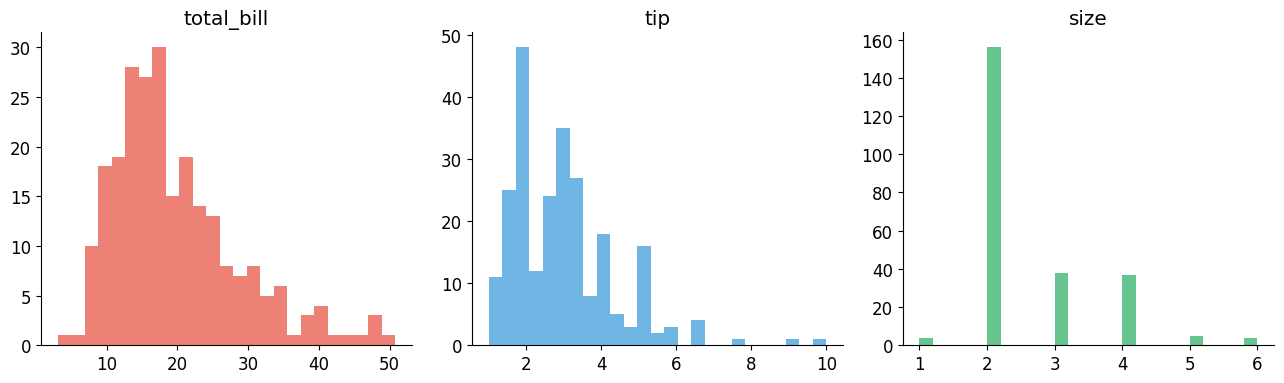

In [13]:
# Exercise 2 – Skewness Diagnosis
cols = ["total_bill", "tip", "size"]
colors = ["#E74C3C", "#3498DB", "#27AE60"]

# 1-3. Loop and classify
for col in cols:
    sk = stats.skew(tips[col].values)
    if abs(sk) < 0.5:
       label = "approximately symmetric"
    elif sk > 0:
       label = "right-skewed (positive tail)"
    else:
       label = "left-skewed (negative tail)"
    print(f"{col:12s}: skew = {sk:.3f} → {label}")

# 4. Histogram grid
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, (col, c) in enumerate(zip(cols, colors)):
    axes[i].hist(tips[col], bins=25, color=c, alpha=0.7)
    axes[i].set_title(col)
plt.tight_layout()

# Deeper Dive: Kurtosis — The Hidden Shape

Kurtosis measures whether the tails of your distribution are **heavier** or **lighter** than a normal distribution.

| Kurtosis (excess) | Name | Characteristic |
|-------------------|------|----------------|
| ≈ 0 | Mesokurtic | Normal distribution tails |
| > 0 (positive) | Leptokurtic | Fat tails — extreme events more common |
| < 0 (negative) | Platykurtic | Thin tails — extreme events less common |

---

### Why It Matters

Stock market returns are often **leptokurtic** (fat tails).

Rare market crashes happen **far more often** than a normal distribution would predict.

Ignoring kurtosis contributed to many risk models failing during the **2008 financial crisis**.

---

> **Live Demo — Kurtosis Comparison Across Subgroups**
>
> Watch how the shape statistics change when we slice the `tips`
> dataset by gender and day.
>
> This gives us a richer picture than looking only at the overall distribution.
```

In [15]:
# Live Demo: Compare skewness and kurtosis across tip subgroups
# Are male tippers shaped differently than female tippers? Does day matter?
# Your code here

for sex in ["Male", "Female"]:
    subset = tips[tips["sex"] == sex]["tip"].values # numpy array
    n = len(subset)
    mean = np.mean(subset)
    skew = stats.skew(subset)
    kurtosis = stats.kurtosis(subset)
    print(f"Group:{sex}; N:{n}; Mean:{mean:.1f}; Skew:{skew:.1f}; Kurtosis:{kurtosis:.1f}")

print()

for day in ['Sun', 'Sat', 'Thur', 'Fri']:
    subset = tips[tips["day"] == day]["tip"].values # numpy array
    n = len(subset)
    mean = np.mean(subset)
    skew = stats.skew(subset)
    kurtosis = stats.kurtosis(subset)
    print(f"Group:{day}; N:{n}; Mean:{mean:.1f}; Skew:{skew:.1f}; Kurtosis:{kurtosis:.1f}")

Group:Male; N:157; Mean:3.1; Skew:1.6; Kurtosis:3.6
Group:Female; N:87; Mean:2.8; Skew:0.7; Kurtosis:0.2

Group:Sun; N:76; Mean:3.3; Skew:0.5; Kurtosis:-0.4
Group:Sat; N:87; Mean:3.0; Skew:2.0; Kurtosis:5.0
Group:Thur; N:62; Mean:2.8; Skew:1.1; Kurtosis:0.6
Group:Fri; N:19; Mean:2.7; Skew:0.2; Kurtosis:-0.8


---

# Part 4: Probability Distributions

<br>

## The Mathematical Models of Reality

---

# The 68–95–99.7 Rule (Empirical Rule)

For any **Normal distribution** with mean **μ** and standard deviation **σ**:

```text
┌───────────────────────────────────────────────┐
│ 68.27% of data within 1σ of the mean          │
│                                               │
│ 95.45% of data within 2σ of the mean          │
│                                               │
│ 99.73% of data within 3σ of the mean          │
└───────────────────────────────────────────────┘
```

## Real-World Implications

- If IQ has **μ = 100** and **σ = 15**:
  - **68%** of people score between **85–115**

- If heights have **μ = 170 cm** and **σ = 10 cm**:
  - **95%** of adults are between **150–190 cm**

- A **"3-sigma event"** is something that happens only **0.27%** of the time

- **"6-sigma"** (Six Sigma in manufacturing):
  - Approximately **3.4 defects per million**

## SciPy Functions for the Normal Distribution

```text
stats.norm.pdf(x, loc=mu, scale=sigma)  # Height of curve at x
stats.norm.cdf(x, loc=mu, scale=sigma)  # P(X <= x) – cumulative
stats.norm.ppf(p, loc=mu, scale=sigma)  # Inverse: what x gives P(X<=x)=p?
stats.norm.rvs(loc=mu, scale=sigma, size=n)  # Random samples
```

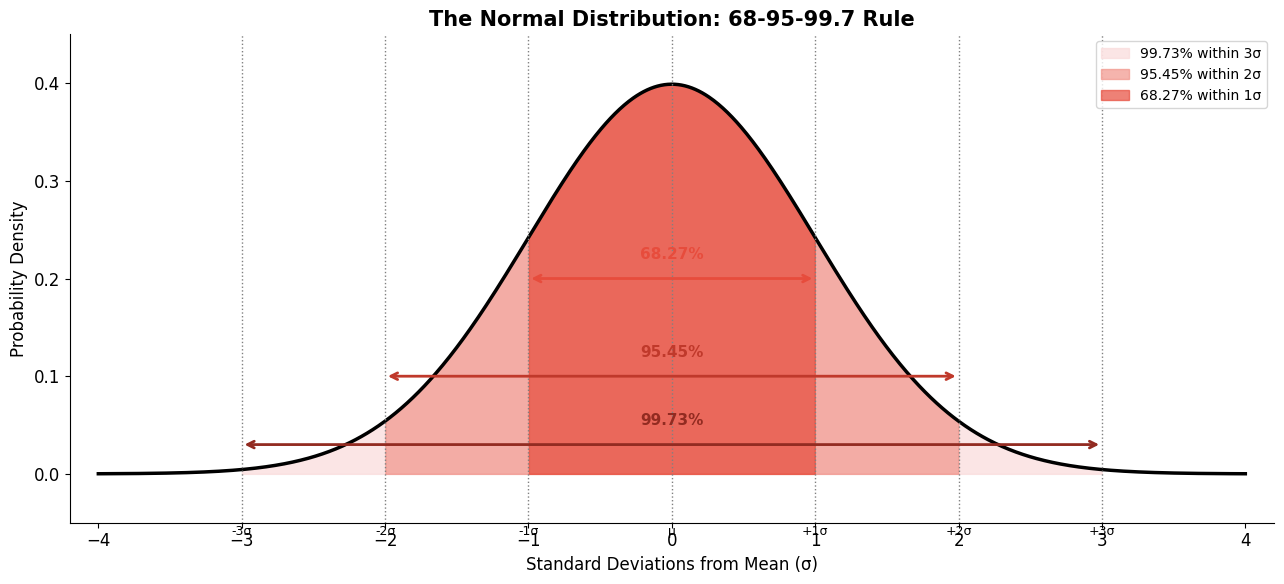

In [16]:
# Visual: 68-95-99.7 Rule with Shaded Areas
fig, ax = plt.subplots(figsize=(13, 6))

mu, sigma = 0, 1
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, mu, sigma)

# Shaded regions (draw widest first, then narrower on top)
fill_configs = [
    (-3, 3, "#FADBDB", "99.73% within 3σ"),
    (-2, 2, "#F1948A", "95.45% within 2σ"),
    (-1, 1, "#E74C3C", "68.27% within 1σ"),
]
for lo, hi, color, label in fill_configs:
    mask = (x >= lo) & (x <= hi)
    ax.fill_between(x[mask], y[mask], alpha=0.7, color=color, label=label)

ax.plot(x, y, "k-", lw=2.5)

# Sigma markers
for s, label in [(-3, "-3σ"), (-2, "-2σ"), (-1, "-1σ"),
                  (0, "μ"), (1, "+1σ"), (2, "+2σ"), (3, "+3σ")]:
    ax.axvline(s, color="gray", lw=1, linestyle=":")
    ax.text(s, -0.025, label, ha="center", fontsize=9,
            transform=ax.get_xaxis_transform())

# Percentage annotations
ax.annotate("", xy=(1, 0.20), xytext=(-1, 0.20),
            arrowprops=dict(arrowstyle="<->", color="#E74C3C", lw=2))
ax.text(0, 0.22, "68.27%", ha="center", color="#E74C3C", fontweight="bold", fontsize=11)

ax.annotate("", xy=(2, 0.10), xytext=(-2, 0.10),
            arrowprops=dict(arrowstyle="<->", color="#C0392B", lw=2))
ax.text(0, 0.12, "95.45%", ha="center", color="#C0392B", fontweight="bold", fontsize=11)

ax.annotate("", xy=(3, 0.03), xytext=(-3, 0.03),
            arrowprops=dict(arrowstyle="<->", color="#922B21", lw=2))
ax.text(0, 0.05, "99.73%", ha="center", color="#922B21", fontweight="bold", fontsize=11)

ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-0.05, 0.45)
ax.set_title("The Normal Distribution: 68-95-99.7 Rule", fontsize=15, fontweight="bold")
ax.set_xlabel("Standard Deviations from Mean (σ)", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

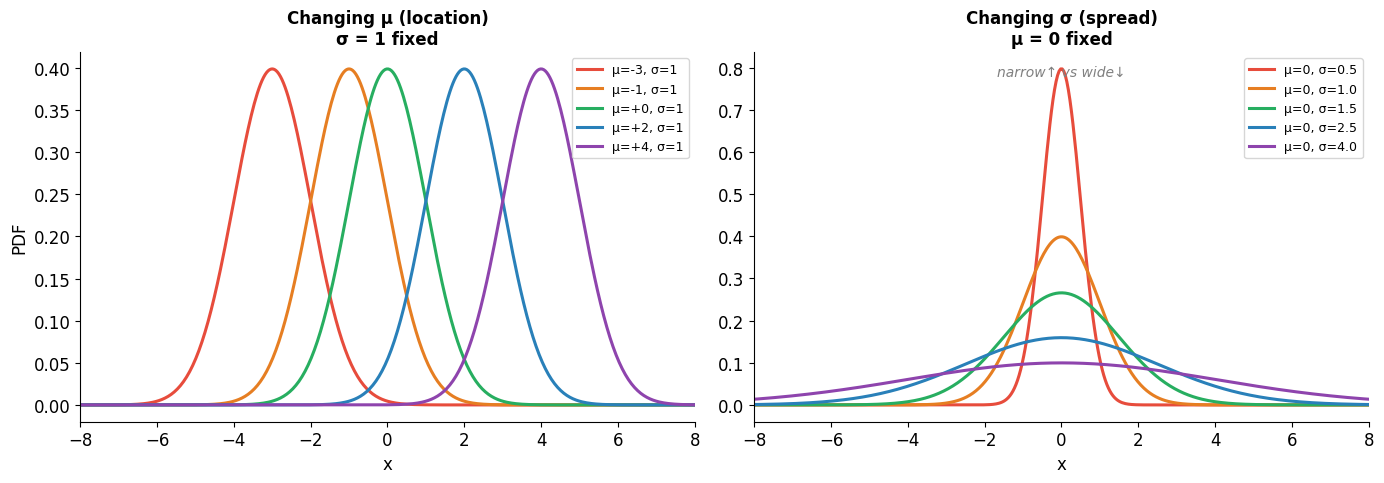

Key: Area under each curve = 1.0 (probability must sum to 100%)


<Figure size 1200x500 with 0 Axes>

Key: Area under each curve = 1.0 (probability must sum to 100%)
  mu=-3: area under curve (within ±10) = 1.000000
  mu=+0: area under curve (within ±10) = 1.000000
  mu=+4: area under curve (within ±10) = 1.000000


In [17]:
# Visual: Normal distribution parameter explorer
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.linspace(-10, 10, 500)

# Left: changing mu (fixed sigma=1)
ax = axes[0]
mu_values = [-3, -1, 0, 2, 4]
colors_mu = ["#E74C3C", "#E67E22", "#27AE60", "#2980B9", "#8E44AD"]
for mu_v, c in zip(mu_values, colors_mu):
    y = stats.norm.pdf(x, loc=mu_v, scale=1)
    ax.plot(x, y, color=c, lw=2.2, label=f"μ={mu_v:+d}, σ=1")
ax.set_title("Changing μ (location)\nσ = 1 fixed", fontsize=12, fontweight="bold")
ax.set_xlabel("x")
ax.set_ylabel("PDF")
ax.legend(fontsize=9)
ax.set_xlim(-8, 8)
ax.annotate("← slides left/right →", xy=(0, 0.42), ha="center",
            fontsize=10, fontstyle="italic", color="gray")

# Right: changing sigma (fixed mu=0)
ax2 = axes[1]
sigma_values = [0.5, 1.0, 1.5, 2.5, 4.0]
colors_sig = ["#E74C3C", "#E67E22", "#27AE60", "#2980B9", "#8E44AD"]
for sig_v, c in zip(sigma_values, colors_sig):
    y = stats.norm.pdf(x, loc=0, scale=sig_v)
    ax2.plot(x, y, color=c, lw=2.2, label=f"μ=0, σ={sig_v}")
ax2.set_title("Changing σ (spread)\nμ = 0 fixed", fontsize=12, fontweight="bold")
ax2.set_xlabel("x")
ax2.legend(fontsize=9)
ax2.set_xlim(-8, 8)
ax2.annotate("narrow↑ vs wide↓", xy=(0, 0.78), ha="center",
             fontsize=10, fontstyle="italic", color="gray")

plt.tight_layout()
plt.show()

print("Key: Area under each curve = 1.0 (probability must sum to 100%)")

ax2 = axes[1]
sigma_values = [0.5, 1.0, 1.5, 2.5, 4.0]
colors_sig = ["#E74C3C", "#E67E22", "#27AE60", "#2980B9", "#8E44AD"]
for sig_v, c in zip(sigma_values, colors_sig):
    y = stats.norm.pdf(x, loc=0, scale=sig_v)
    ax2.plot(x, y, color=c, lw=2.2, label=f"μ=0, σ={sig_v}")
ax2.set_title("Changing σ (spread)\nμ = 0 fixed", fontsize=12, fontweight="bold")
ax2.set_xlabel("x")
ax2.legend(fontsize=9)
ax2.set_xlim(-8, 8)
ax2.annotate("narrow↑ vs wide↓", xy=(0, 0.78), ha="center",
             fontsize=10, fontstyle="italic", color="gray")

plt.tight_layout()
plt.show()

print("Key: Area under each curve = 1.0 (probability must sum to 100%)")
for mu_v in [-3, 0, 4]:
    area = stats.norm.cdf(10, mu_v, 1) - stats.norm.cdf(-10, mu_v, 1)
    print(f"  mu={mu_v:+d}: area under curve (within ±10) = {area:.6f}")


    

In [20]:
# Live Demo: PDF and CDF - answering real questions
# Question: What fraction of bills are above $30?
# CDF: P(bill <= 30)
# Compare to actual data
# Your code here

mu_bill = tips["total_bill"].mean()
sigma_bill = tips["total_bill"].std()

# CDF: P(bill <= 30)
p_below_30 = stats.norm.cdf(30, loc=mu_bill, scale=sigma_bill)
p_above_30 = 1 - p_below_30

print(f"Model (Normal approximation):")
print(f"  P(bill <= 30): {p_below_30} = {p_below_30*100}%")
print(f"  P(bill > 30): {p_above_30} = {p_above_30*100}%")

# Compare to actual data
actual_above_30 = (tips['total_bill'] > 30).mean()
print("Actual data")
print(f"  Fraction above $30: {actual_above_30} = {actual_above_30*100}%")
print(f"  (Model vs actual difference: {abs(p_above_30 - actual_above_30) * 100}%")

Model (Normal approximation):
  P(bill <= 30): 0.8743786015484053 = 87.43786015484054%
  P(bill > 30): 0.1256213984515947 = 12.56213984515947%
Actual data
  Fraction above $30: 0.13114754098360656 = 13.114754098360656%
  (Model vs actual difference: 0.5526142532011863%
